# LRE-like spatial validation panel

## tl;dr

The primary positive panel for the Pristina anterior/mid-intestine 2
LRE-like hypothesis contains five translated lysosomal/protein-digestion
genes: `fuca1.1`, `hexb`, `ctsl.1`, `ctsbb`, and `naga`. The canonical
zebrafish LRE machinery candidates `cubn`, `dab2`, and `amn` are not
enriched in this Pristina population, so they are context checks rather
than primary positive probes.

## Context & Methods

The panel begins with zebrafish LRE markers translated to Pristina by
the precomputed BLAST table. Pristina expression was normalized to
10,000 counts per cell and log1p transformed. Primary panel candidates
require high alignment support, positive target-versus-other expression,
and a detection-fraction difference above 0.05.

**Key assumption:** BLAST alignment supports a candidate homology
relationship; it does not prove one-to-one orthology or conserved
function. The literature rationale for the zebrafish LRE program is
Park et al. (2019), *Developmental Cell*,
doi:10.1016/j.devcel.2019.08.001.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "public_results").exists():
    ROOT = ROOT.parent
PUBLIC = ROOT / "public_results"

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})

## Data

In [2]:
panel = pd.read_csv(PUBLIC / "lre_validation_panel.csv")
context = pd.read_csv(PUBLIC / "lre_mechanistic_context_checks.csv")
panel[[
    "panel_rank", "gene_symbol", "pristina_gene", "identity",
    "alignment_length", "pristina_log2_fc_target_vs_other",
    "pristina_target_detection_fraction", "pristina_detection_difference",
]]

,panel_rank,gene_symbol,pristina_gene,identity,alignment_length,pristina_log2_fc_target_vs_other,pristina_target_detection_fraction,pristina_detection_difference
0,1,fuca1.1,PrileiEVm011523t1,57.143,455,3.712423,0.579767,0.554020
1,2,hexb,PrileiEVm008813t1,56.897,522,3.667236,0.546693,0.521747
2,3,ctsl.1,PrileiEVm014063t1,64.286,294,2.122331,0.357977,0.288747
3,4,ctsbb,PrileiEVm014379t1,62.379,311,2.660090,0.186770,0.175327
4,5,naga,PrileiEVm012889t1,52.507,379,2.776806,0.237354,0.220991


## Results

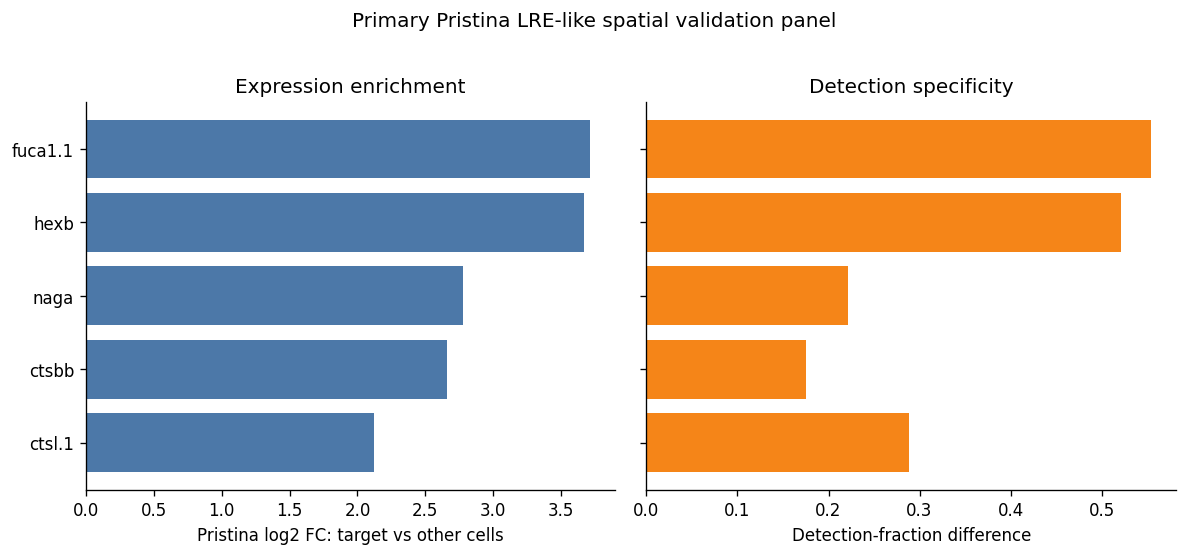

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharey=True)
plot_data = panel.sort_values("pristina_log2_fc_target_vs_other")
axes[0].barh(plot_data["gene_symbol"], plot_data["pristina_log2_fc_target_vs_other"], color="#4C78A8")
axes[0].set_xlabel("Pristina log2 FC: target vs other cells")
axes[0].set_title("Expression enrichment")
axes[1].barh(plot_data["gene_symbol"], plot_data["pristina_detection_difference"], color="#F58518")
axes[1].set_xlabel("Detection-fraction difference")
axes[1].set_title("Detection specificity")
fig.suptitle("Primary Pristina LRE-like spatial validation panel", y=1.02)
fig.tight_layout()
plt.show()

In [4]:
context[[
    "gene_symbol", "pristina_gene", "homology_quality",
    "pristina_log2_fc_target_vs_other", "pristina_target_detection_fraction",
    "context_check",
]]

,gene_symbol,pristina_gene,homology_quality,pristina_log2_fc_target_vs_other,pristina_target_detection_fraction,context_check
0,dab2,PrileiEVm002583t1,moderate,-0.114437,0.001946,Not a primary positive probe: not enriched/det...
1,amn,PrileiEVm005481t1,moderate,0.011965,0.001946,Not a primary positive probe: not enriched/det...
2,cubn,PrileiEVm000171t1,high,-0.107186,0.000000,Not a primary positive probe: not enriched/det...


## Takeaways

- Use several primary panel genes together; a multiplex spatial pattern
  is more informative than any individual gene.
- The panel tests whether anterior/mid-intestine 2 has a coherent
  lysosomal/protein-digestion program.
- The absence of `cubn`, `dab2`, or `amn` enrichment means the current
  data do not support simply calling these Pristina cells canonical
  zebrafish LREs. Their function and orthology require independent
  investigation.